## **1. Import Libraries:**

In [ ]:
!pip install xgboost
!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import optuna

In [ ]:
np.random.seed(42)

## **2. Data Inspection:**

In [ ]:
df = pd.read_csv(f"ER Wait Time Dataset.csv")

In [ ]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [ ]:
# Shape and column info
print(df.shape) # (rows, columns)
print(df.columns) # column names
print(df.info())  # types, non-null counts

# Missing values
print(df.isnull().sum())

# Duplicates
print(df.duplicated().sum())


(5000, 19)
Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   

## **3. Data Preproccing:**

In [ ]:
df = df.drop(columns=[
    'Nurse-to-Patient Ratio', 'Specialist Availability',
    'Facility Size (Beds)', 'Patient Outcome',
    'Patient Satisfaction', 'Visit ID',
    'Patient ID', 'Time to Registration (min)',
    'Visit Date', 'Time to Triage (min)',
    'Time to Medical Professional (min)'
])

df.head()

,Hospital ID,Hospital Name,Region,Day of Week,Season,Time of Day,Urgency Level,Total Wait Time (min)
0,HOSP-1,Springfield General Hospital,Urban,Saturday,Winter,Late Morning,Medium,105
1,HOSP-3,Northside Community Hospital,Rural,Thursday,Fall,Evening,Medium,69
2,HOSP-3,Northside Community Hospital,Rural,Monday,Fall,Evening,Low,203
3,HOSP-2,Riverside Medical Center,Urban,Tuesday,Winter,Evening,High,88
4,HOSP-1,Springfield General Hospital,Urban,Wednesday,Spring,Afternoon,Low,118


In [ ]:
# Rename columns
df.rename(columns={
    'Hospital ID':   'Hospital_ID',
    'Hospital Name': 'Hospital_Name',
    'Region':        'City',
    'Day of Week':   'Day_of_Week',
    'Time of Day':   'Time_of_Day',
    'Urgency Level': 'painLevel',
    'Total Wait Time (min)': 'actualWaitMins'
}, inplace=True)

print(df.columns)
print(df['Hospital_ID'].unique())
print(df['Hospital_Name'].unique())
print(df['City'].unique())

Index(['Hospital_ID', 'Hospital_Name', 'City', 'Day_of_Week', 'Season',
       'Time_of_Day', 'painLevel', 'actualWaitMins'],
      dtype='object')
['HOSP-1' 'HOSP-3' 'HOSP-2' 'HOSP-5' 'HOSP-4']
['Springfield General Hospital' 'Northside Community Hospital'
 'Riverside Medical Center' 'Summit Health Center'
 'St. Mary’s Regional Health']
['Urban' 'Rural']


In [ ]:
# Hospital metadata — maps old IDs to QLife hospital names
hospital_info = {
    'HOSP-1': {'name': 'Al-Mana Medical Center',         'branch': 'Main',       'city': 'Jubail'},
    'HOSP-2': {'name': 'Al-Mana Medical Center',         'branch': 'Al-Rakah',   'city': 'Dammam'},
    'HOSP-3': {'name': 'Al-Mana General Hospital',       'branch': 'Al-Aziziah', 'city': 'Dammam'},
    'HOSP-4': {'name': 'Al-Mana General Hospital',       'branch': 'Main',       'city': 'Khobar'},
    'HOSP-5': {'name': 'Al-Mana General Hospital',       'branch': 'Main',       'city': 'Dammam'},
    'HOSP-6': {'name': 'Al-Mana General Hospital',       'branch': 'Main',       'city': 'Jubail'},
    'HOSP-7': {'name': 'Dr. Sulaiman Al Habib Hospital', 'branch': 'Main',       'city': 'Khobar'},
    'HOSP-8': {'name': 'Saudi German Hospital',          'branch': 'Main',       'city': 'Dammam'},
    'HOSP-9': {'name': 'King Fahad University Hospital', 'branch': 'Main',       'city': 'Dammam'},
}

id_mapping = {
    'HOSP-1': 1, 'HOSP-2': 2, 'HOSP-3': 3,
    'HOSP-4': 4, 'HOSP-5': 5, 'HOSP-6': 6,
    'HOSP-7': 7, 'HOSP-8': 8, 'HOSP-9': 9
}

In [ ]:
# Randomly assign 30% of rows to the 4 newer hospitals
new_hospitals = ['HOSP-6', 'HOSP-7', 'HOSP-8', 'HOSP-9']
mask = np.random.rand(len(df)) < 0.3
df.loc[mask, 'Hospital_ID'] = np.random.choice(new_hospitals, size=mask.sum())

# Map hospital metadata
df['Hospital_Name'] = df['Hospital_ID'].map(lambda x: hospital_info[x]['name'])
df['branch']        = df['Hospital_ID'].map(lambda x: hospital_info[x]['branch'])
df['City']          = df['Hospital_ID'].map(lambda x: hospital_info[x]['city'])

# Convert Hospital_ID string → integer
df['Hospital_ID'] = df['Hospital_ID'].map(id_mapping)

print(df['Hospital_ID'].unique())
df.head()

[1 3 2 8 9 7 4 6 5]


,Hospital_ID,Hospital_Name,City,Day_of_Week,Season,Time_of_Day,painLevel,actualWaitMins,branch
0,1,Al-Mana Medical Center,Jubail,Saturday,Winter,Late Morning,Medium,105,Main
1,3,Al-Mana General Hospital,Dammam,Thursday,Fall,Evening,Medium,69,Al-Aziziah
2,3,Al-Mana General Hospital,Dammam,Monday,Fall,Evening,Low,203,Al-Aziziah
3,2,Al-Mana Medical Center,Dammam,Tuesday,Winter,Evening,High,88,Al-Rakah
4,8,Saudi German Hospital,Dammam,Wednesday,Spring,Afternoon,Low,118,Main


In [ ]:
N = 8000

days    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
times   = ['Early Morning','Morning','Late Morning','Afternoon','Evening','Night']
seasons = ['Spring','Summer','Autumn','Winter']
pains   = ['Critical','High','Medium','Low']

hosp_keys = list(hospital_info.keys())
hosp_ids  = np.random.choice(hosp_keys, size=N)
day_col   = np.random.choice(days,    size=N)
time_col  = np.random.choice(times,   size=N)

df = pd.DataFrame({
    'Hospital_Name': [hospital_info[h]['name']   for h in hosp_ids],
    'City':          [hospital_info[h]['city']   for h in hosp_ids],
    'branch':        [hospital_info[h]['branch'] for h in hosp_ids],
    'Day_of_Week':   day_col,
    'Season':        np.random.choice(seasons, size=N),
    'Time_of_Day':   time_col,
    'painLevel':     np.random.choice(pains,   size=N),
})


In [ ]:
def generate_queue_length(row):
    base = {
        'Early Morning': np.random.randint(1, 5),
        'Morning':       np.random.randint(3, 10),
        'Late Morning':  np.random.randint(5, 14),
        'Afternoon':     np.random.randint(8, 18),
        'Evening':       np.random.randint(10, 22),
        'Night':         np.random.randint(2, 9),
    }.get(row['Time_of_Day'], np.random.randint(3, 12))

    # Saudi weekends are busier
    if row['Day_of_Week'] in ['Thursday', 'Friday']:
        base = min(base + np.random.randint(2, 6), 25)

    return max(1, base)

df['Queue_length'] = df.apply(generate_queue_length, axis=1)

df.columns = df.columns.str.strip()
df.head()

,Hospital_Name,City,branch,Day_of_Week,Season,Time_of_Day,painLevel,Queue_length
0,Al-Mana Medical Center,Jubail,Main,Sunday,Spring,Early Morning,High,2
1,Al-Mana Medical Center,Jubail,Main,Thursday,Summer,Late Morning,Critical,8
2,Al-Mana General Hospital,Khobar,Main,Saturday,Autumn,Morning,Critical,6
3,Al-Mana General Hospital,Khobar,Main,Thursday,Winter,Afternoon,Low,10
4,Al-Mana Medical Center,Dammam,Al-Rakah,Wednesday,Winter,Night,Low,5


In [ ]:
# Confirm no missing values or duplicates in clean df
print(df.isnull().sum())
print(df.duplicated().sum())

Hospital_Name    0
City             0
branch           0
Day_of_Week      0
Season           0
Time_of_Day      0
painLevel        0
Queue_length     0
dtype: int64
660


## **4. Statistical Analysis:**

In [ ]:
df.describe()

,Queue_length
count,8000.000000
mean,9.551625
std,5.437052
min,1.000000
25%,5.000000
50%,9.000000
75%,13.000000
max,25.000000


In [ ]:
df.describe()

numeric_df = df.select_dtypes(include=[np.number])

Q1  = numeric_df.quantile(0.25)
Q3  = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower    = Q1 - 1.5 * IQR
upper    = Q3 + 1.5 * IQR
outliers = ((numeric_df < lower) | (numeric_df > upper)).sum()
print(outliers)


Queue_length    0
dtype: int64


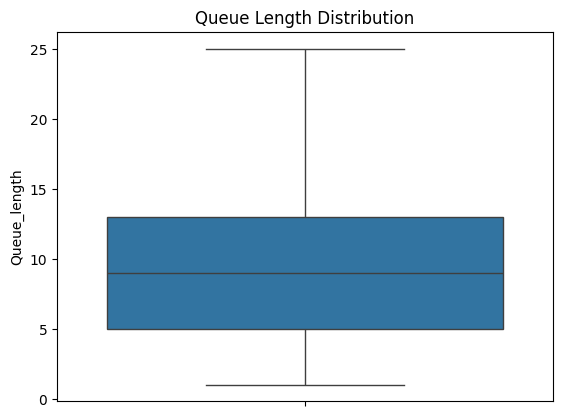

In [ ]:
## Boxplot visualization for Queue Length
sns.boxplot(df['Queue_length'])
plt.title('Queue Length Distribution')
plt.show()

In [ ]:
print(df['Hospital_Name'].value_counts())
print(df['City'].value_counts())
print(df[['Queue_length']].describe())
print(df.groupby(['City', 'branch']).size())
print(df['painLevel'].value_counts())


Hospital_Name
Al-Mana General Hospital          3538
Al-Mana Medical Center            1802
Dr. Sulaiman Al Habib Hospital     902
Saudi German Hospital              882
King Fahad University Hospital     876
Name: count, dtype: int64
City
Dammam    4408
Jubail    1803
Khobar    1789
Name: count, dtype: int64
       Queue_length
count   8000.000000
mean       9.551625
std        5.437052
min        1.000000
25%        5.000000
50%        9.000000
75%       13.000000
max       25.000000
City    branch    
Dammam  Al-Aziziah     880
        Al-Rakah       883
        Main          2645
Jubail  Main          1803
Khobar  Main          1789
dtype: int64
painLevel
High        2053
Low         1989
Critical    1980
Medium      1978
Name: count, dtype: int64


# **5. Customization**:

In [ ]:
def calculate_realistic_wait(row):

    # 1. Queue component (~30%) — capped at 20 to avoid dominating
    effective_queue = min(row['Queue_length'], 20)
    queue_component = effective_queue * np.random.uniform(2.0, 3.5)

    # 2. Pain level component (~20–25%) — critical = fast-tracked
    pain_component = {
        'Critical': np.random.uniform(-25, -15),
        'High':     np.random.uniform(-10,  -3),
        'Medium':   np.random.uniform(  5,  15),
        'Low':      np.random.uniform( 18,  30),
    }.get(row['painLevel'], 0)

    # 3. Time of day component (~15–20%)
    time_component = {
        'Evening':       np.random.uniform(20, 35),
        'Afternoon':     np.random.uniform(12, 25),
        'Late Morning':  np.random.uniform( 5, 15),
        'Morning':       np.random.uniform( 0, 10),
        'Night':         np.random.uniform( 8, 18),
        'Early Morning': np.random.uniform(-8,  2),
    }.get(row['Time_of_Day'], 0)

    # 4. Hospital component (~10–15%)
    hospital_component = {
        'Al-Mana Medical Center':        np.random.uniform(-20, -10),
        'Saudi German Hospital':         np.random.uniform(-15,  -5),
        'Dr. Sulaiman Al Habib Hospital':np.random.uniform(-10,   0),
        'Al-Mana General Hospital':      np.random.uniform( -5,   5),
        'King Fahad University Hospital':np.random.uniform(  5,  15),
    }.get(row['Hospital_Name'], 0)

    # 5. Day of week component (~5–10%)
    day_component = {
        'Thursday': np.random.uniform( 8, 15),
        'Friday':   np.random.uniform(10, 18),
        'Saturday': np.random.uniform( 3,  8),
    }.get(row['Day_of_Week'], np.random.uniform(0, 5))

    # 6. Season component (~3–5%)
    season_component = {
        'Summer': np.random.uniform(3, 8),
        'Winter': np.random.uniform(2, 6),
        'Spring': np.random.uniform(0, 3),
        'Autumn': np.random.uniform(0, 3),
    }.get(row['Season'], 0)

    # 7. Noise — real-world unpredictability
    noise = np.random.normal(0, 6)

    return max(5, round(
        queue_component + pain_component + time_component +
        hospital_component + day_component + season_component + noise
    ))

df['actualWaitMins'] = df.apply(calculate_realistic_wait, axis=1)

In [ ]:
# check average wait per pain level
# should be: Critical < High < Medium < Low
print("\nAverage wait by pain level:")
print(df.groupby('painLevel')['actualWaitMins'].mean().sort_values())

print("\nAverage wait by time of day:")
print(df.groupby('Time_of_Day')['actualWaitMins'].mean().sort_values())

print("\nAverage wait by hospital:")
print(df.groupby('Hospital_Name')['actualWaitMins'].mean().sort_values())


Average wait by pain level:
painLevel
Critical    26.282323
High        38.375548
Medium      53.827098
Low         66.398693
Name: actualWaitMins, dtype: float64

Average wait by time of day:
Time_of_Day
Early Morning    18.878788
Morning          32.445600
Night            36.607752
Late Morning     44.647332
Afternoon        61.324946
Evening          78.041209
Name: actualWaitMins, dtype: float64

Average wait by hospital:
Hospital_Name
Al-Mana Medical Center            37.192009
Saudi German Hospital             39.119048
Dr. Sulaiman Al Habib Hospital    46.176275
Al-Mana General Hospital          49.676936
King Fahad University Hospital    57.568493
Name: actualWaitMins, dtype: float64


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

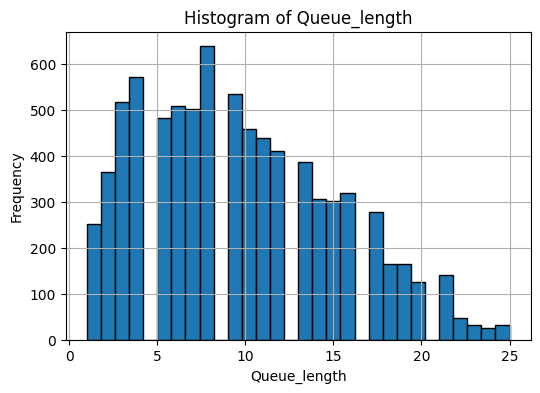

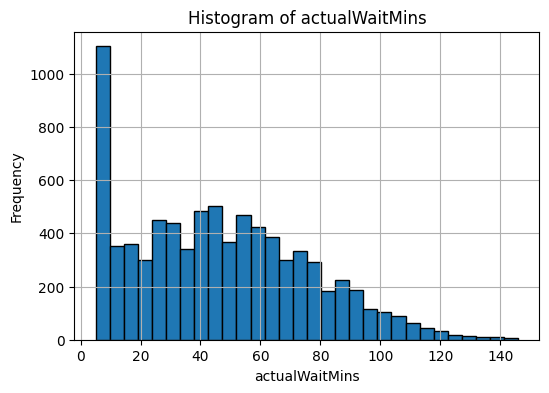

In [ ]:
## Plots a histogram for a given column in a DataFrame to inspect the distribution and potential outliers.
def plot_histogram(df, column_name):
    plt.figure(figsize=(6, 4))
    df[column_name].hist(bins=30, edgecolor='black')
    plt.title(f"Histogram of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.show()
# Queue_length, actualWaitMins  usage:
plot_histogram(df, 'Queue_length')
plot_histogram(df, 'actualWaitMins')

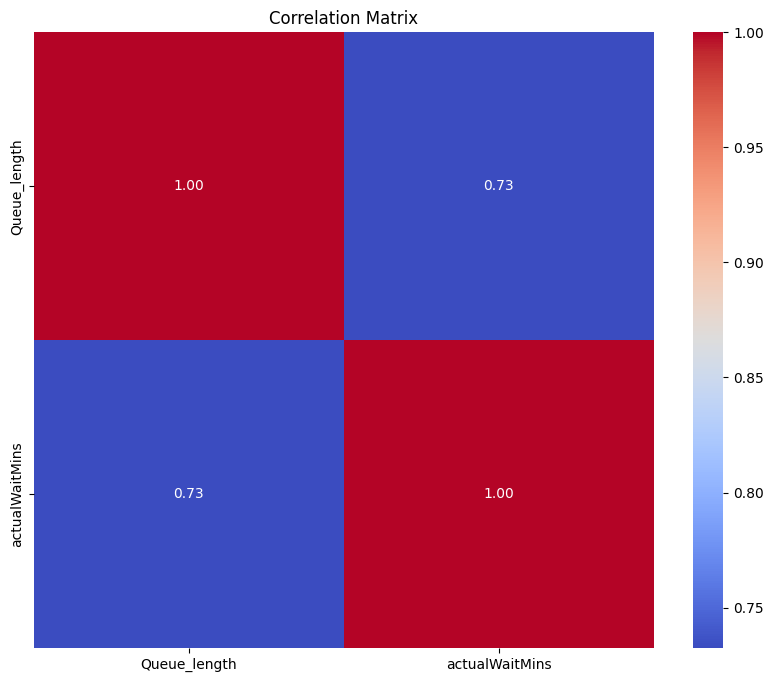

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

/tmp/ipykernel_5999/2485449325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='painLevel', y='actualWaitMins', data=df, palette='viridis')


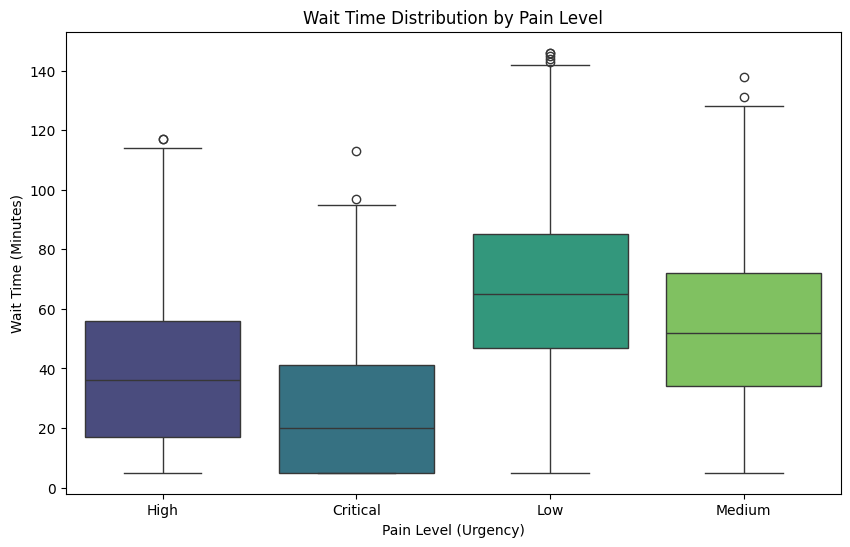

In [ ]:
## Relationship between pain level and actual waiting time (Wait time by pain level)
plt.figure(figsize=(10, 6))
sns.boxplot(x='painLevel', y='actualWaitMins', data=df, palette='viridis')
plt.title('Wait Time Distribution by Pain Level')
plt.xlabel('Pain Level (Urgency)')
plt.ylabel('Wait Time (Minutes)')
plt.show()

Average Wait Time per City:
 City
Jubail    42.447587
Dammam    46.980036
Khobar    47.926216
Name: actualWaitMins, dtype: float64


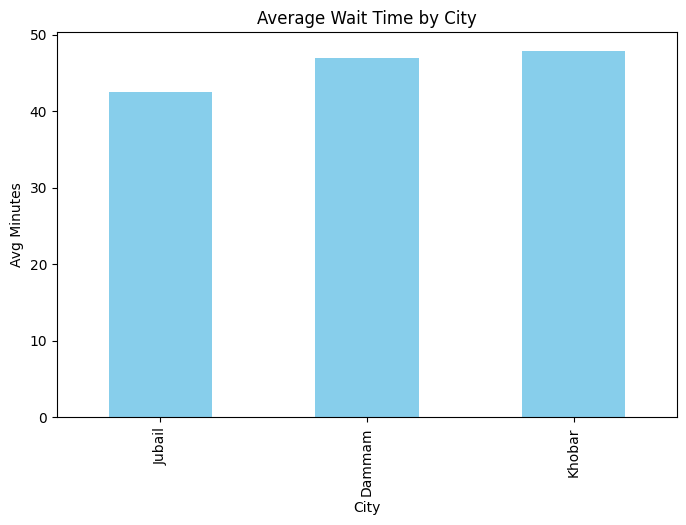

In [ ]:
# Average waiting time for each city
city_wait = df.groupby('City')['actualWaitMins'].mean().sort_values()
print("Average Wait Time per City:\n", city_wait)

# Plot the relationship
plt.figure(figsize=(8, 5))
city_wait.plot(kind='bar', color='skyblue')
plt.title('Average Wait Time by City')
plt.ylabel('Avg Minutes')
plt.show()

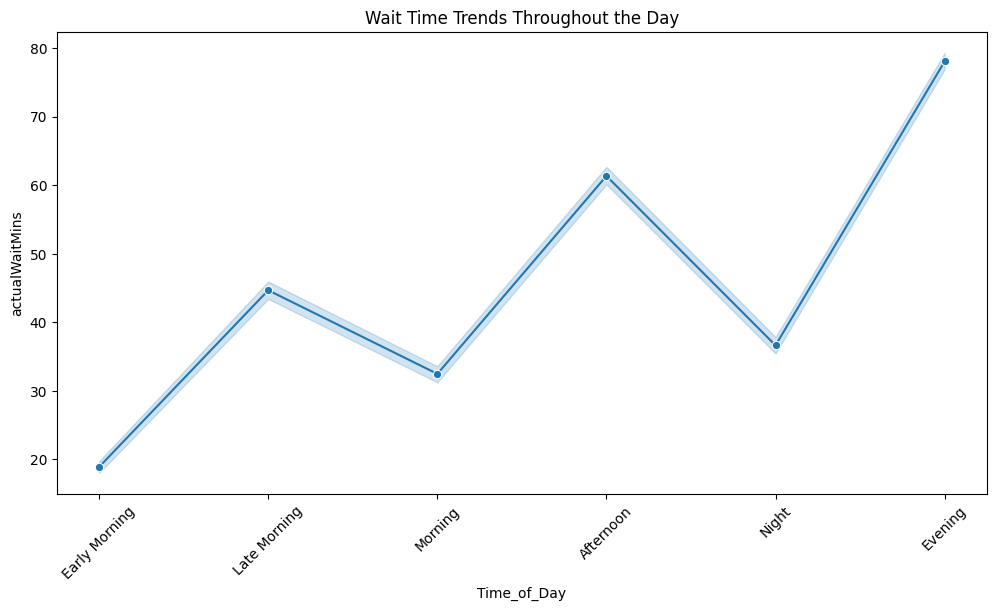

In [ ]:
## Time of the day analysis - Wait time trend by time of day
plt.figure(figsize=(12, 6))
sns.lineplot(x='Time_of_Day', y='actualWaitMins', data=df, marker='o')
plt.title('Wait Time Trends Throughout the Day')
plt.xticks(rotation=45)
plt.show()

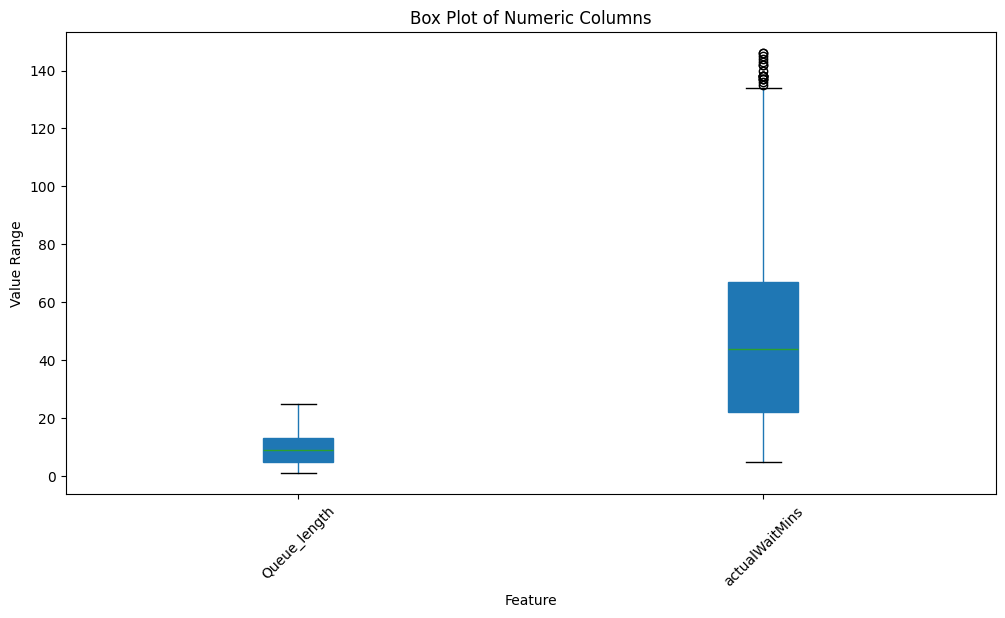

In [ ]:
# Boxplot of numeric columns
plt.figure(figsize=(12, 6))
numeric_df.boxplot(grid=False, patch_artist=True)
plt.title('Box Plot of Numeric Columns')
plt.xlabel('Feature')
plt.ylabel('Value Range')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df = df[[
    'Hospital_Name', 'City', 'branch',
    'Day_of_Week', 'Season', 'Time_of_Day',
    'painLevel', 'Queue_length', 'actualWaitMins'
]]

df.columns = df.columns.str.strip()

df.head()

,Hospital_Name,City,branch,Day_of_Week,Season,Time_of_Day,painLevel,Queue_length,actualWaitMins
0,Al-Mana Medical Center,Jubail,Main,Sunday,Spring,Early Morning,High,2,5
1,Al-Mana Medical Center,Jubail,Main,Thursday,Summer,Late Morning,Critical,8,5
2,Al-Mana General Hospital,Khobar,Main,Saturday,Autumn,Morning,Critical,6,6
3,Al-Mana General Hospital,Khobar,Main,Thursday,Winter,Afternoon,Low,10,64
4,Al-Mana Medical Center,Dammam,Al-Rakah,Wednesday,Winter,Night,Low,5,45


## **6. Feature Engineering:**

In [ ]:
pain_weights = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df['Medical_Priority_Score'] = df['painLevel'].map(pain_weights) * df['Queue_length']

peak_times = ['Evening', 'Afternoon']
df['Is_Peak_Time'] = df['Time_of_Day'].apply(lambda x: 1 if x in peak_times else 0)

df['Day_Time_Comb'] = df['Day_of_Week'] + "_" + df['Time_of_Day']

In [ ]:
le_daytime = LabelEncoder()
df['Day_Time_Comb'] = le_daytime.fit_transform(df['Day_Time_Comb'])

le_time = LabelEncoder()
df['Time_Numeric'] = le_time.fit_transform(df['Time_of_Day'])
df['Queue_Effect_by_Time'] = df['Queue_length'] * df['Time_Numeric']

In [ ]:
print("Data after feature engineering:")
print(df[['painLevel', 'Queue_length', 'Medical_Priority_Score',
          'Is_Peak_Time', 'Day_Time_Comb', 'Queue_Effect_by_Time']].head())

Data after feature engineering:
  painLevel  Queue_length  Medical_Priority_Score  Is_Peak_Time  \
0      High             2                       6             0   
1  Critical             8                      32             0   
2  Critical             6                      24             0   
3       Low            10                      10             1   
4       Low             5                       5             0   

   Day_Time_Comb  Queue_Effect_by_Time  
0             19                     2  
1             27                    24  
2             16                    24  
3             24                     0  
4             41                    25  


In [ ]:
# Save engineered data to CSV
df.to_csv('QLife_Engineered_Data.csv', index=False)

print(df.columns)

Index(['Hospital_Name', 'City', 'branch', 'Day_of_Week', 'Season',
       'Time_of_Day', 'painLevel', 'Queue_length', 'actualWaitMins',
       'Medical_Priority_Score', 'Is_Peak_Time', 'Day_Time_Comb',
       'Time_Numeric', 'Queue_Effect_by_Time'],
      dtype='object')


### **7. Train and Test the data with the models:**

In [ ]:
## Define features (x) and target (y)
#X = df[['Hospital_Name', 'branch', 'City', 'Day_of_Week', 'Time_of_Day', 'painLevel', 'Queue_length']]
#y = df['actualWaitMins']

FEATURE_COLS = [
    'Hospital_Name', 'branch', 'City', 'Day_of_Week', 'Time_of_Day',
    'painLevel', 'Queue_length',
    'Medical_Priority_Score', 'Is_Peak_Time', 'Day_Time_Comb', 'Queue_Effect_by_Time'
]

X = df[FEATURE_COLS]
y = df['actualWaitMins']

In [ ]:
label_encoders = {}
X_encoded = X.copy()

categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le  # save each one

# the two special encoders from Section 6
label_encoders['_day_time_comb_source'] = le_daytime
label_encoders['_time_numeric_source']  = le_time


In [ ]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print(y.describe())

Number of samples: 8000
Number of features: 11
count    8000.000000
mean       46.170125
std        29.541966
min         5.000000
25%        22.000000
50%        44.000000
75%        67.000000
max       146.000000
Name: actualWaitMins, dtype: float64


In [ ]:
# Train/test split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data prepared for training!")

Data prepared for training!


**Linear Regression Model:**


 Linear Regression 
R2 Score (Accuracy): 78.67%
MAE                : 10.63 mins

Overfitting Check
Training R2 : 79.45%
Testing  R2 : 78.67%


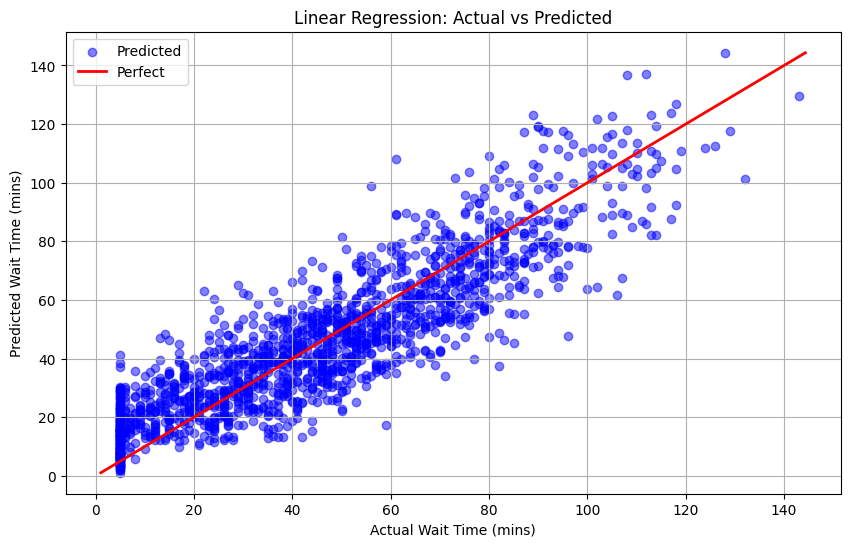

In [ ]:
# Choose a model (LinearRegression)
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = linear_model.predict(X_test_scaled)

print("\n Linear Regression ")
## Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE                : {mean_absolute_error(y_test, y_pred):.2f} mins")

## Check for overfitting
print("\nOverfitting Check")
print(f"Training R2 : {r2_score(y_train, linear_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred)*100:.2f}%")


# -----------------------------
# Visualize predictions
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

**Ridge Regression Model:**


 Ridge Regression 
R2 Score (Accuracy): 78.67%
MAE                : 10.63 mins

Overfitting Check
Training R2 : 79.45%
Testing  R2 : 78.67%


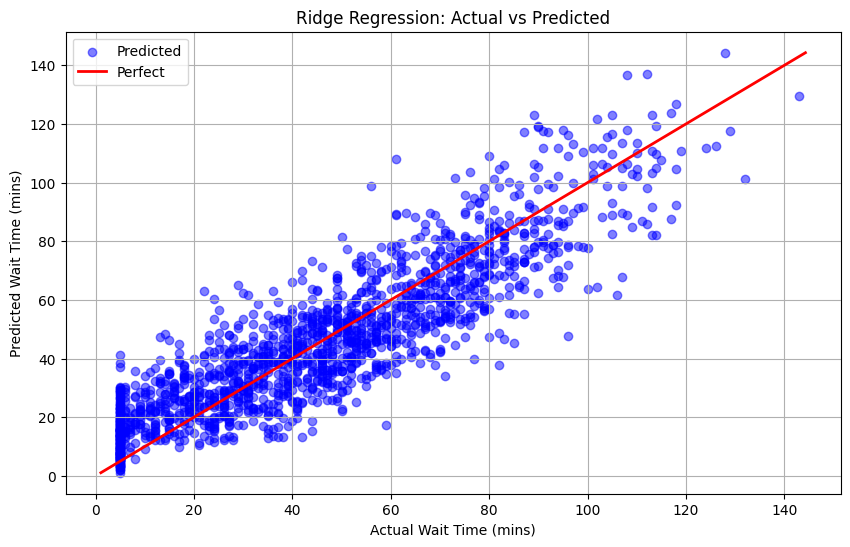

In [ ]:
# Choose a model (Ridge Regression)
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = ridge_model.predict(X_test_scaled)

print("\n Ridge Regression ")
## Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE                : {mean_absolute_error(y_test, y_pred):.2f} mins")


## Check for overfitting
print("\nOverfitting Check")
print(f"Training R2 : {r2_score(y_train, linear_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred)*100:.2f}%")


# -----------------------------
# Visualize predictions
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('Ridge Regression: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

**KNN Model:**


 KNN 
R2 Score (Accuracy): 85.76%
MAE         : 8.30 mins
Training R2 : 90.60%
Testing  R2 : 85.76%


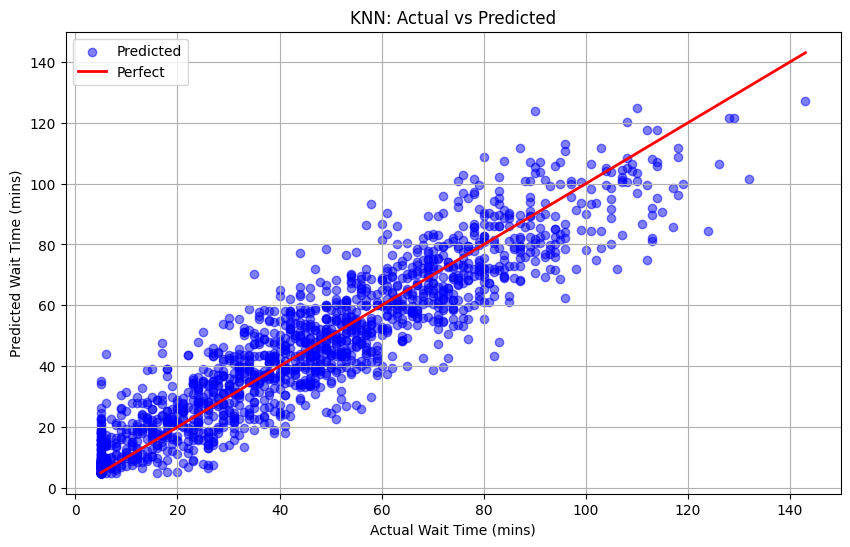

In [ ]:
# Choose a model (KNN)
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)
# Make predictions
y_pred = knn.predict(X_test_scaled)

print("\n KNN ")
# Evaluate model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred):.2f} mins")

# Check overfitting
print(f"Training R2 : {r2_score(y_train, knn.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred)*100:.2f}%")


# -----------------------------
# Visualize predictions
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('KNN: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

**Decision Tree Model:**


 Decision Tree 
R2 Score (Accuracy): 77.24%
MAE         : 10.65 mins
Training R2 : 78.13%
Testing  R2 : 77.24%


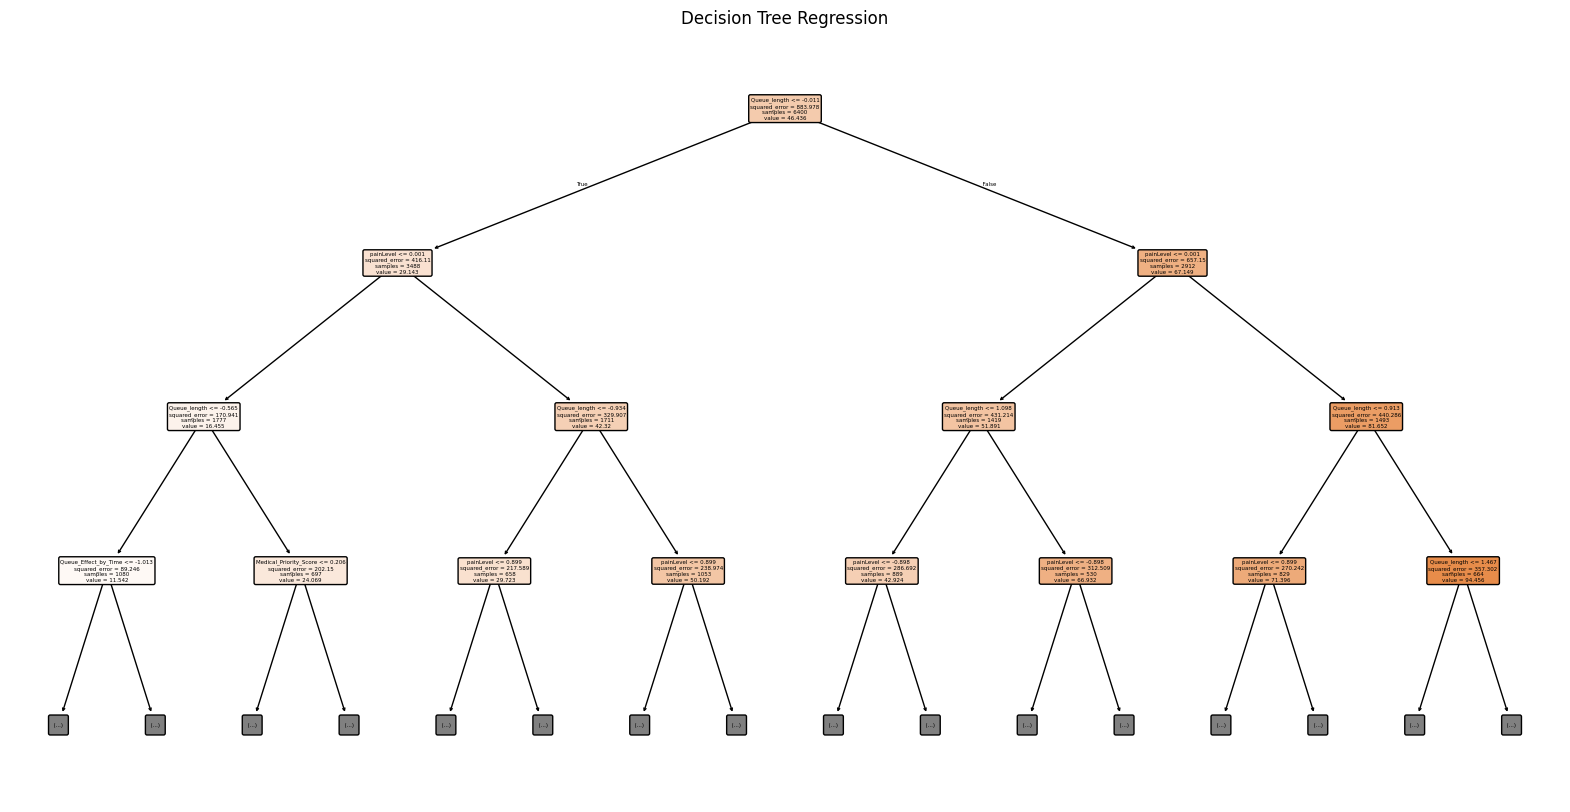

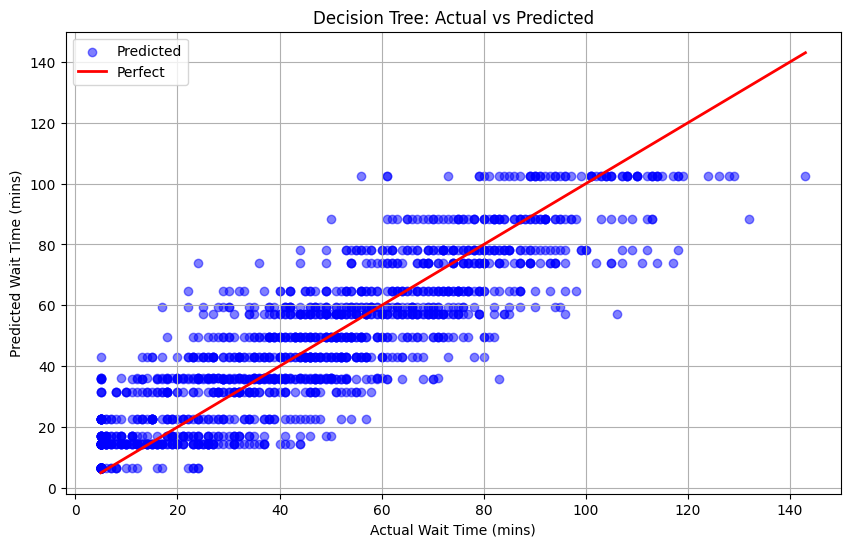

In [ ]:
# Choose a model (Decision Tree)
DecisionTree_model = DecisionTreeRegressor(max_depth=4, # Limit depth to prevent overfitting
                                           min_samples_split=5,
                                           random_state=42)

# Train the model
DecisionTree_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = DecisionTree_model.predict(X_test_scaled)

print("\n Decision Tree ")
# Evaluate model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, DecisionTree_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred)*100:.2f}%")


# -----------------------------
#    Visualize predictions
# -----------------------------

plt.figure(figsize=(20, 10))
plot_tree(DecisionTree_model, feature_names=X_encoded.columns.tolist(),
          filled=True, rounded=True, max_depth=3)
plt.title("Decision Tree Regression"); plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

**Random Forest Model:**


 Random Forest 
R2 Score (Accuracy): 86.95%
MAE         : 7.96 mins
Training R2 : 96.87%
Testing  R2 : 86.95%


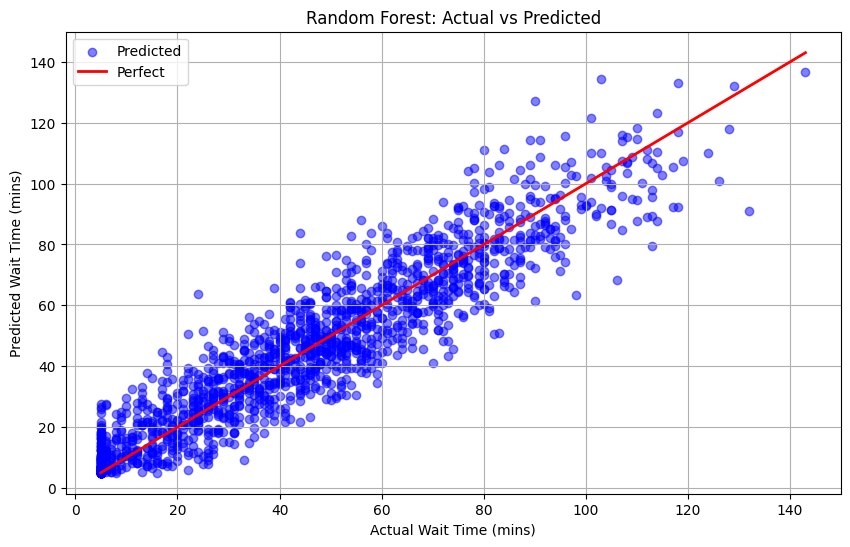

In [ ]:
# Choose a model (Random Forest)
rf_model = RandomForestRegressor(
    n_estimators=110,        # number of trees
    max_depth=None,          # let trees expand fully
    random_state=42,
    n_jobs=-1                # use all CPU cores
    )

# Train the model
rf_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = rf_model.predict(X_test_scaled)

print("\n Random Forest ")
# Evaluate model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, rf_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred)*100:.2f}%")


# -----------------------------
#    Visualize predictions
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

In [ ]:
## Hyperparameter tunning using GridSearch
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5]}


grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search_rf.fit(X_train_scaled, y_train)

y_pred_gr = grid_search_rf.best_estimator_.predict(X_test_scaled)


print(f"RF GridSearch, Best params: {grid_search_rf.best_params_}")
print(f"R2: {r2_score(y_test, y_pred_gr)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_gr):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, grid_search_rf.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_gr)*100:.2f}%")


RF GridSearch, Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
R2: 81.31%
MAE         : 9.75 mins
Training R2 : 82.24%
Testing  R2 : 81.31%


In [ ]:
## Hyperparameter tunning using Random search (RandomizedSearch tuning)
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
    }


rs_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                           rf_param_dist,
                           n_iter=10,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1,
                           random_state=42)


rs_rf.fit(X_train_scaled, y_train)

y_pred_rf_rs = rs_rf.best_estimator_.predict(X_test_scaled)


print(f"RF RandomSearch, Best score: {rs_rf.best_score_*100:.2f}%")
print(f"R2: {r2_score(y_test, y_pred_rf_rs)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_rf_rs):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, rs_rf.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_rf_rs)*100:.2f}%")

RF RandomSearch, Best score: 86.49%
R2: 87.44%
MAE         : 7.84 mins
Training R2 : 94.11%
Testing  R2 : 87.44%


In [ ]:
# Random Forest - Bayesian (Optuna) tuning
def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 400),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 15),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    return cross_val_score(RandomForestRegressor(**params, random_state=42),
                           X_train_scaled, y_train, cv=5, scoring='r2').mean()


# use a named study so it doesn't conflict with XGBoost study below
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)
print(f"RF Bayesian best CV: {study_rf.best_value*100:.2f}%")

Bayesian_rf_model = RandomForestRegressor(**study_rf.best_params, random_state=42)

Bayesian_rf_model.fit(X_train_scaled, y_train)

y_pred_Bayesian = Bayesian_rf_model.predict(X_test_scaled)

print(f"RF Bayesian — R2: {r2_score(y_test, y_pred_Bayesian)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_Bayesian):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, Bayesian_rf_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_Bayesian)*100:.2f}%")

[I 2026-05-07 23:54:02,617] A new study created in memory with name: no-name-8107c256-4fe9-42e7-b559-c49728873b9e
[I 2026-05-07 23:54:05,521] Trial 0 finished with value: 0.713540490359613 and parameters: {'n_estimators': 232, 'max_depth': 3, 'min_samples_split': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.713540490359613.
[I 2026-05-07 23:54:08,981] Trial 1 finished with value: 0.7131533774547655 and parameters: {'n_estimators': 289, 'max_depth': 3, 'min_samples_split': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.713540490359613.
[I 2026-05-07 23:54:16,020] Trial 2 finished with value: 0.8350691165923447 and parameters: {'n_estimators': 170, 'max_depth': 6, 'min_samples_split': 10, 'max_features': None}. Best is trial 2 with value: 0.8350691165923447.
[I 2026-05-07 23:54:17,641] Trial 3 finished with value: 0.8500221400155622 and parameters: {'n_estimators': 74, 'max_depth': 8, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 3 with value: 0.8

RF Bayesian best CV: 85.57%
RF Bayesian — R2: 85.66%
MAE         : 8.47 mins
Training R2 : 87.59%
Testing  R2 : 85.66%


**XGBoost Model:**


 ------ XGBoost ------
R2 Score (Accuracy): 89.52%
MAE         : 7.37 mins
Training R2 : 90.17%
Testing  R2 : 89.52%


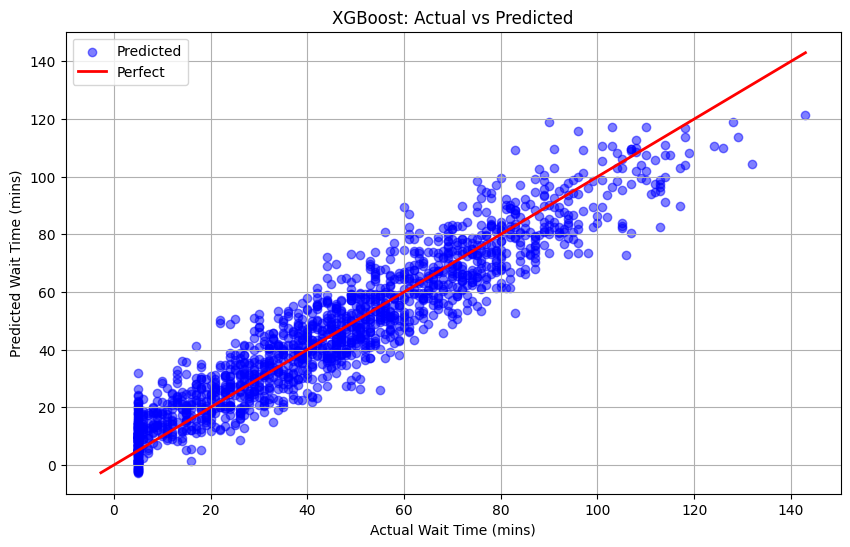

In [ ]:
# Choose a model (XGBoost)
xg_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

# Train the model
xg_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred_xg = xg_model.predict(X_test_scaled)

print("\n ------ XGBoost ------")
# Evaluate model
r2 = r2_score(y_test, y_pred_xg)
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_xg):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, xg_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_xg)*100:.2f}%")


# -----------------------------
#    Visualize predictions
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xg, alpha=0.5, color='blue', label='Predicted')
v = [min(min(y_test), min(y_pred_xg)), max(max(y_test), max(y_pred_xg))]

plt.plot(v, v, 'r-', lw=2, label='Perfect')
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Wait Time (mins)')
plt.ylabel('Predicted Wait Time (mins)')
plt.legend(); plt.grid(True); plt.show()

In [ ]:
## Hyper tune using GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xg_grid_search = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, cv=5, scoring='r2')

xg_grid_search.fit(X_train_scaled, y_train)
y_pred_xg_gs = xg_grid_search.predict(X_test_scaled)

print(f"XGBoost GridSearch, Best params: {xg_grid_search.best_params_}")
print(f"R2: {r2_score(y_test, y_pred_xg_gs)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_xg_gs):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, xg_grid_search.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_xg_gs)*100:.2f}%")

XGBoost GridSearch, Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
R2: 89.85%
MAE         : 7.24 mins
Training R2 : 90.72%
Testing  R2 : 89.85%


In [ ]:
# XGBoost — RandomizedSearch tuning
param_dist = {
    'n_estimators':    [100, 300, 500, 700],
    'max_depth':       [3, 4, 5, 6],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.7, 0.8, 0.9, 1.0]
}

random_search_xg = RandomizedSearchCV(xgb.XGBRegressor(random_state=42), param_dist,
                                      n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)

random_search_xg.fit(X_train_scaled, y_train)
y_pred_xg_rs = random_search_xg.predict(X_test_scaled)

print(f"XGBoost RandomSearch, Best score: {random_search_xg.best_score_*100:.2f}%")
print(f"R2: {r2_score(y_test, y_pred_xg_rs)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_xg_rs):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, random_search_xg.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_xg_rs)*100:.2f}%")


XGBoost RandomSearch, Best score: 89.71%
R2: 89.89%
MAE         : 7.22 mins
Training R2 : 90.85%
Testing  R2 : 89.89%


In [ ]:
# XGBoost - Bayesian (Optuna) tuning - Cross Validation
def objective_xg(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample':        trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'random_state': 42
    }
    return cross_val_score(xgb.XGBRegressor(**params), X_train_scaled, y_train, cv=5, scoring='r2').mean()


study_xg = optuna.create_study(direction='maximize')
study_xg.optimize(objective_xg, n_trials=25)
print(f"XGBoost Bayesian best CV: {study_xg.best_value*100:.2f}%")
print(f"Best params: {study_xg.best_params}")

final_xg_model = xgb.XGBRegressor(**study_xg.best_params, random_state=42)
final_xg_model.fit(X_train_scaled, y_train)
y_pred_xg_cv = final_xg_model.predict(X_test_scaled)

print(f"\n XGBoost Final (Bayesian tuned) ")
print(f"R2: {r2_score(y_test, y_pred_xg_cv)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_xg_cv):.2f} mins")

## Check overfitting
print(f"Training R2 : {r2_score(y_train, final_xg_model.predict(X_train_scaled))*100:.2f}%")
print(f"Testing  R2 : {r2_score(y_test, y_pred_xg_cv)*100:.2f}%")

[I 2026-05-07 23:56:33,630] A new study created in memory with name: no-name-0c0aa55c-3d38-47d1-871a-d388893ded1a
[I 2026-05-07 23:56:35,337] Trial 0 finished with value: 0.8837595582008362 and parameters: {'n_estimators': 475, 'max_depth': 4, 'learning_rate': 0.19537776255840822, 'subsample': 0.743515472473677, 'colsample_bytree': 0.743177348999255}. Best is trial 0 with value: 0.8837595582008362.
[I 2026-05-07 23:56:38,221] Trial 1 finished with value: 0.8971715450286866 and parameters: {'n_estimators': 272, 'max_depth': 4, 'learning_rate': 0.043547692017411696, 'subsample': 0.6071336046059811, 'colsample_bytree': 0.7678917884361146}. Best is trial 1 with value: 0.8971715450286866.
[I 2026-05-07 23:56:39,734] Trial 2 finished with value: 0.8815055131912232 and parameters: {'n_estimators': 298, 'max_depth': 6, 'learning_rate': 0.09457451236681025, 'subsample': 0.7612266518584305, 'colsample_bytree': 0.8004910443613849}. Best is trial 1 with value: 0.8971715450286866.
[I 2026-05-07 23:

XGBoost Bayesian best CV: 89.73%
Best params: {'n_estimators': 411, 'max_depth': 3, 'learning_rate': 0.0557765528874297, 'subsample': 0.8334511617392633, 'colsample_bytree': 0.8534500602340926}

 XGBoost Final (Bayesian tuned) 
R2: 89.84%
MAE         : 7.23 mins
Training R2 : 90.87%
Testing  R2 : 89.84%



Feature Importances:
               Feature  Importance
          Is_Peak_Time    0.347519
          Queue_length    0.273221
             painLevel    0.225347
         Hospital_Name    0.040047
Medical_Priority_Score    0.037616
  Queue_Effect_by_Time    0.033593
           Time_of_Day    0.016238
           Day_of_Week    0.013947
         Day_Time_Comb    0.006946
                branch    0.003564
                  City    0.001963


/tmp/ipykernel_5999/88077268.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


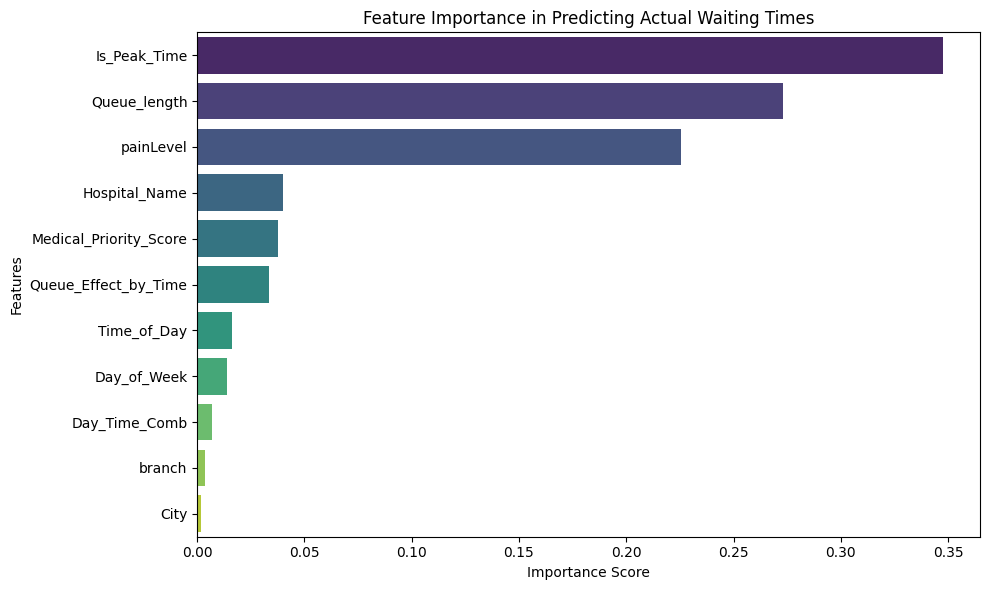

In [ ]:
# use final_xg_model to show importance from the best model.
feature_importances = final_xg_model.feature_importances_
feature_names       = FEATURE_COLS

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance in Predicting Actual Waiting Times")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## From the result:
# 1. Evening/Afternoon are genuinely the strongest ER predictor - this is backed by real hospital research worldwide
# 2. Triage priority directly controls how fast you're seen
# 3. Important but not dominating - healthy share
# 4. (Time_of_Day) Adds detail beyond just peak/not-peak (Night vs Morning differ)
# 5. (Medical_Priority_Score) Combined signal of pain × queue - logical interaction
# 6. (Queue_Effect_by_Time) Queue at peak hours hits harder than queue at 5am
# 7. (Hospital_Name) Different hospitals have different staffing
# 8. (Day_of_Week) weekends are slightly busier

## -----------------------------------------------------------------------------------------------------------
# "ER wait time is primarily driven by whether it's peak hours,
# followed by how urgent your case is,
# then how many people are ahead of you - with the specific hospital and day adding smaller adjustments."
## -----------------------------------------------------------------------------------------------------------

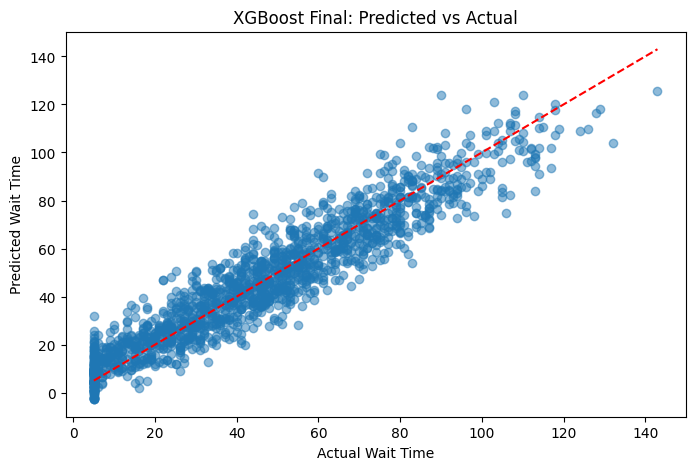

In [ ]:
# Predicted vs Actual scatter (final model)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_xg_cv, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("XGBoost Final: Predicted vs Actual")
plt.show()

## **8. Compare between the models:**

/tmp/ipykernel_5999/4195516400.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='R2 (%)', data=results_df, palette='husl')


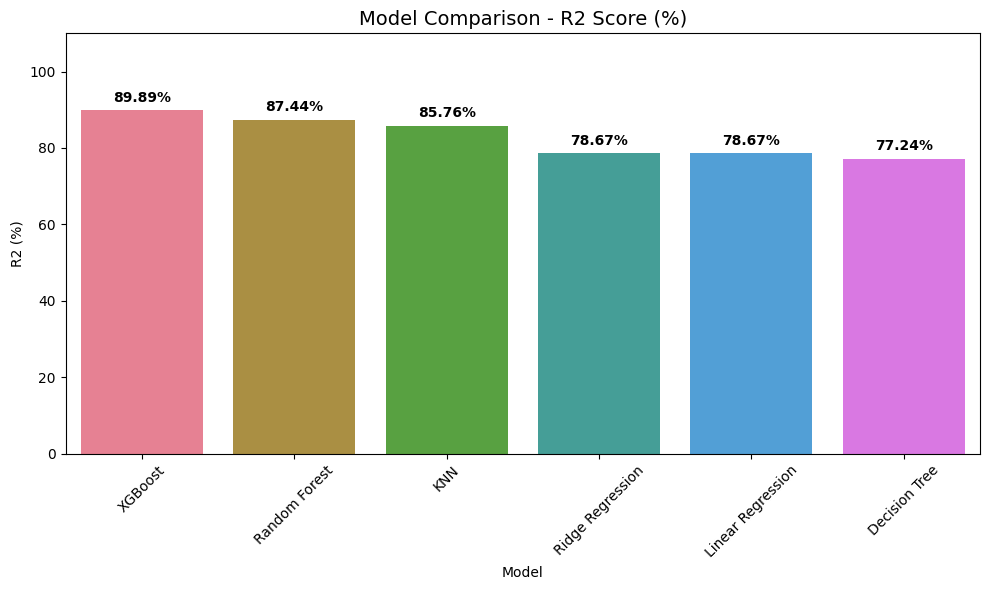

            Model    R2 (%)       MAE      RMSE
          XGBoost 89.887047  7.223656  9.138346
    Random Forest 87.438340  7.835079 10.184793
              KNN 85.761260  8.300875 10.843375
 Ridge Regression 78.670281 10.629629 13.271538
Linear Regression 78.668947 10.629632 13.271953
    Decision Tree 77.235410 10.650716 13.710667


In [ ]:
models = {
    'Random Forest':    rs_rf,
    'Linear Regression':linear_model,
    'Ridge Regression': ridge_model,
    'KNN':              knn,
    'Decision Tree':    DecisionTree_model,
    'XGBoost':          random_search_xg,
}

results = []
for name, m in models.items():
    yp   = m.predict(X_test_scaled)
    r2   = r2_score(y_test, yp) * 100
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    results.append({'Model': name, 'R2 (%)': r2, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results).sort_values('R2 (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='R2 (%)', data=results_df, palette='husl')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=10, fontweight='bold')
plt.title('Model Comparison - R2 Score (%)', fontsize=14)
plt.ylabel('R2 (%)')
plt.xlabel('Model')
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))


## **9. Save Artifacts for API**

In [ ]:
import joblib

# Extract the best model from RandomizedSearchCV
production_model = random_search_xg.best_estimator_

# Confirm its performance before saving
y_pred_prod = production_model.predict(X_test_scaled)
print(f" ── Production Model (RandomSearch best) ── ")
print(f"Best params : {random_search_xg.best_params_}")
print(f"R2          : {r2_score(y_test, y_pred_prod)*100:.2f}%")
print(f"MAE         : {mean_absolute_error(y_test, y_pred_prod):.2f} mins")

# Save all 4 artifacts
joblib.dump(production_model, 'xgboost_model.joblib')
joblib.dump(scaler,           'scaler.joblib')
joblib.dump(label_encoders,   'label_encoders.joblib')
joblib.dump(FEATURE_COLS,     'feature_columns.joblib')

print("\nAll artifacts saved.")
print("  xgboost_model.joblib")
print("  scaler.joblib")
print("  label_encoders.joblib")
print("  feature_columns.joblib")

 ── Production Model (RandomSearch best) ── 
Best params : {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
R2          : 89.89%
MAE         : 7.22 mins

All artifacts saved.
  xgboost_model.joblib
  scaler.joblib
  label_encoders.joblib
  feature_columns.joblib
